In [1]:
print('Đề bài: ', 2251262571 % 20 + 1)

Đề bài:  12


In [25]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [3]:
df = pd.read_csv('Sunspots.csv')
df

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7
...,...,...,...
3260,3260,2020-09-30,0.6
3261,3261,2020-10-31,14.4
3262,3262,2020-11-30,34.0
3263,3263,2020-12-31,21.8


In [4]:
df.describe()

,Unnamed: 0,Monthly Mean Total Sunspot Number
count,3265.000000,3265.000000
mean,1632.000000,81.778775
std,942.668641,67.889277
min,0.000000,0.000000
25%,816.000000,23.900000
50%,1632.000000,67.200000
75%,2448.000000,122.500000
max,3264.000000,398.200000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         3265 non-null   int64  
 1   Date                               3265 non-null   object 
 2   Monthly Mean Total Sunspot Number  3265 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 76.7+ KB


In [6]:
df.isnull().sum()

Unnamed: 0                           0
Date                                 0
Monthly Mean Total Sunspot Number    0
dtype: int64

In [13]:
df = df.rename(columns={'Unnamed: 0': 'ID'})

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID                                 3265 non-null   int64  
 1   Date                               3265 non-null   object 
 2   Monthly Mean Total Sunspot Number  3265 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 76.7+ KB


In [18]:
sunspots = df['Monthly Mean Total Sunspot Number']

ADF Test for Original Series:
ADF Statistic: -10.497051662546149
p-value: 1.1085524921956106e-18
Critical Values:
   1%: -3.4323724026124003
   5%: -2.8624335760905684
   10%: -2.5672456699774324
--> Chuỗi Original Series có vẻ dừng (stationary) vì p-value < 0.05

ADF Test for First Differenced Series:
ADF Statistic: -9.11077308695153
p-value: 3.404382306009541e-15
Critical Values:
   1%: -3.4323730282726124
   5%: -2.8624338524376807
   10%: -2.5672458170990113
--> Chuỗi First Differenced Series có vẻ dừng (stationary) vì p-value < 0.05

ADF Test for Second Differenced Series:
ADF Statistic: -18.902771026273786
p-value: 0.0
Critical Values:
   1%: -3.4323711524522436
   5%: -2.8624330239086477
   10%: -2.5672453760070444
--> Chuỗi Second Differenced Series có vẻ dừng (stationary) vì p-value < 0.05



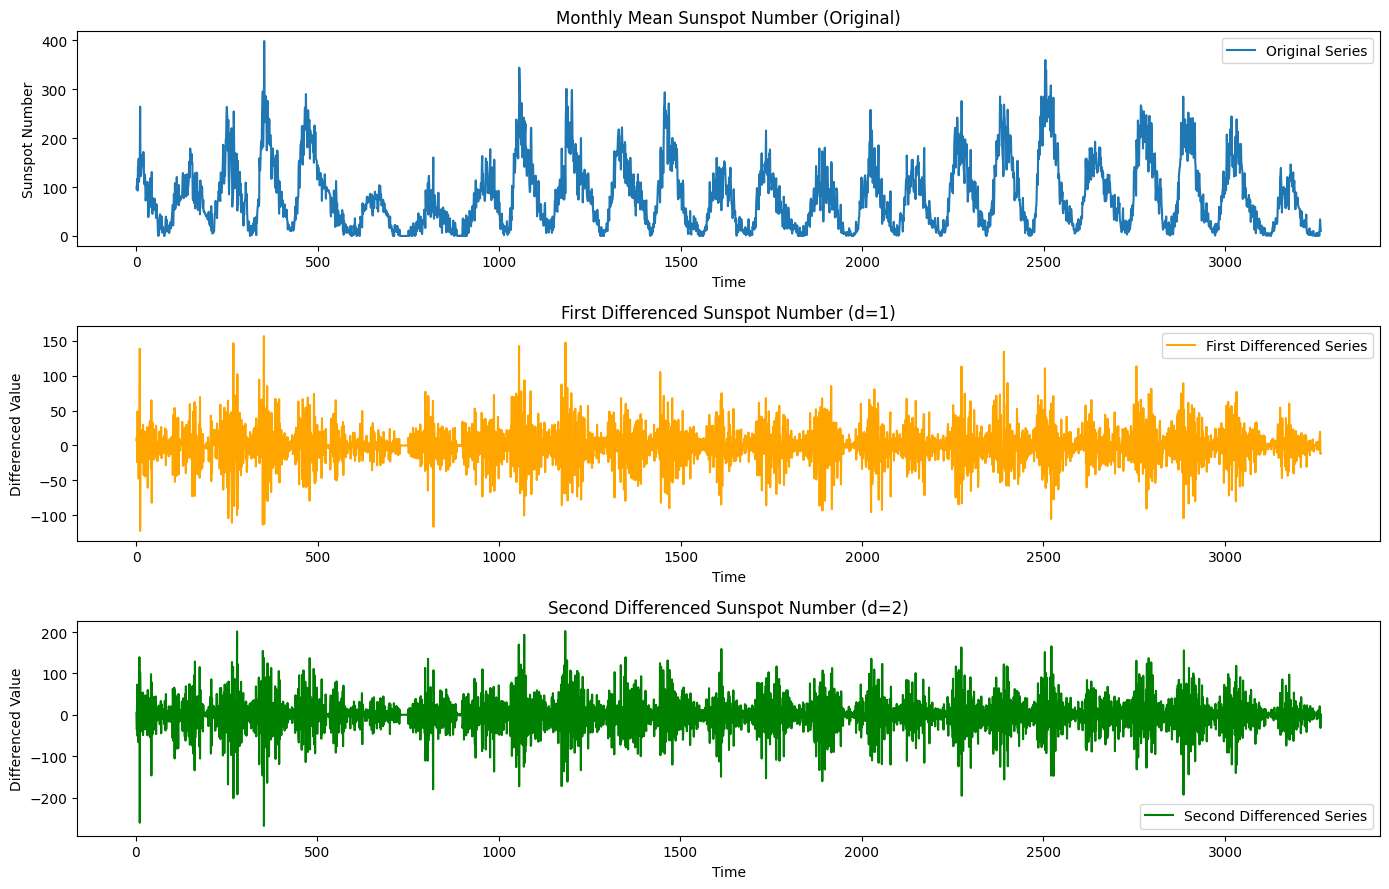

In [24]:
# Hàm kiểm tra tính dừng với ADF
def check_stationarity(timeseries, title):
    result = adfuller(timeseries.dropna())
    print(f'ADF Test for {title}:')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    if result[1] < 0.05:
        print(f'--> Chuỗi {title} có vẻ dừng (stationary) vì p-value < 0.05\n')
    else:
        print(f'--> Chuỗi {title} không dừng (non-stationary) vì p-value >= 0.05\n')

# Kiểm tra tính dừng của chuỗi gốc
check_stationarity(sunspots, "Original Series")

# Chỉnh sửa d tại đây: Sai phân lần thứ nhất (d=1)
sunspots_diff1 = sunspots.diff().dropna()  # d=1: Sai phân lần thứ nhất
check_stationarity(sunspots_diff1, "First Differenced Series")

# Nếu muốn thử d=2 (sai phân lần thứ hai), thêm dòng sau
sunspots_diff2 = sunspots_diff1.diff().dropna()  # d=2: Sai phân lần thứ hai
check_stationarity(sunspots_diff2, "Second Differenced Series")

# Vẽ biểu đồ chuỗi gốc và chuỗi sai phân để quan sát
plt.figure(figsize=(14, 9))

plt.subplot(3, 1, 1)
plt.plot(sunspots, label='Original Series')
plt.title('Monthly Mean Sunspot Number (Original)')
plt.xlabel('Time')
plt.ylabel('Sunspot Number')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(sunspots_diff1, label='First Differenced Series', color='orange')
plt.title('First Differenced Sunspot Number (d=1)')
plt.xlabel('Time')
plt.ylabel('Differenced Value')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(sunspots_diff2, label='Second Differenced Series', color='green')
plt.title('Second Differenced Sunspot Number (d=2)')
plt.xlabel('Time')
plt.ylabel('Differenced Value')
plt.legend()

plt.tight_layout()
plt.show()

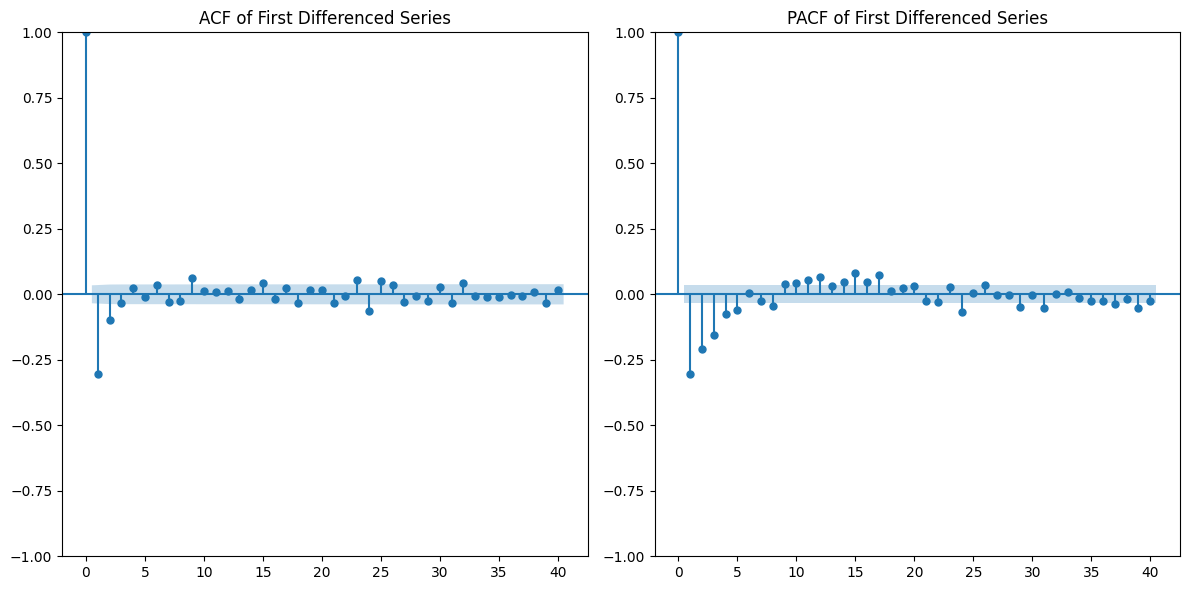

In [28]:
# Vẽ ACF và PACF để chọn p và q
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(sunspots_diff1, lags=40, ax=plt.gca())
plt.title('ACF of First Differenced Series')
plt.subplot(122)
plot_pacf(sunspots_diff1, lags=40, ax=plt.gca())
plt.title('PACF of First Differenced Series')
plt.tight_layout()
plt.show()

In [48]:
# Khớp mô hình ARIMA(p, d, q) - Thử với (1, 1, 1)
p, d, q = 2, 1, 2  # Có thể điều chỉnh p và q dựa trên ACF/PACF
model = ARIMA(sunspots, order=(p, d, q))
model_fit = model.fit()

In [49]:
# In tóm tắt mô hình
print("\nTóm tắt mô hình ARIMA({},{},{}):".format(p, d, q))
print(model_fit.summary())


Tóm tắt mô hình ARIMA(2,1,2):
                                       SARIMAX Results                                       
Dep. Variable:     Monthly Mean Total Sunspot Number   No. Observations:                 3265
Model:                                ARIMA(2, 1, 2)   Log Likelihood              -15120.479
Date:                               Tue, 03 Jun 2025   AIC                          30250.958
Time:                                       15:19:32   BIC                          30281.412
Sample:                                            0   HQIC                         30261.865
                                              - 3265                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3251      0.021     64.184      0.000     

In [50]:
# Dự báo 12 tháng tiếp theo
forecast = model_fit.forecast(steps=60)
print("\nDự báo 12 tháng tiếp theo:")
print(forecast)


Dự báo 12 tháng tiếp theo:
3265    12.922901
3266    14.568040
3267    15.797285
3268    16.806205
3269    17.679897
3270    18.457425
3271    19.158487
3272    19.794461
3273    20.373002
3274    20.899968
3275    21.380232
3276    21.818050
3277    22.217220
3278    22.581173
3279    22.913025
3280    23.215609
3281    23.491509
3282    23.743079
3283    23.972464
3284    24.181621
3285    24.372334
3286    24.546228
3287    24.704788
3288    24.849365
3289    24.981193
3290    25.101396
3291    25.210999
3292    25.310936
3293    25.402061
3294    25.485150
3295    25.560912
3296    25.629992
3297    25.692981
3298    25.750416
3299    25.802785
3300    25.850536
3301    25.894077
3302    25.933778
3303    25.969978
3304    26.002985
3305    26.033082
3306    26.060525
3307    26.085547
3308    26.108364
3309    26.129168
3310    26.148137
3311    26.165434
3312    26.181205
3313    26.195586
3314    26.208698
3315    26.220655
3316    26.231556
3317    26.241497
3318    26.250561


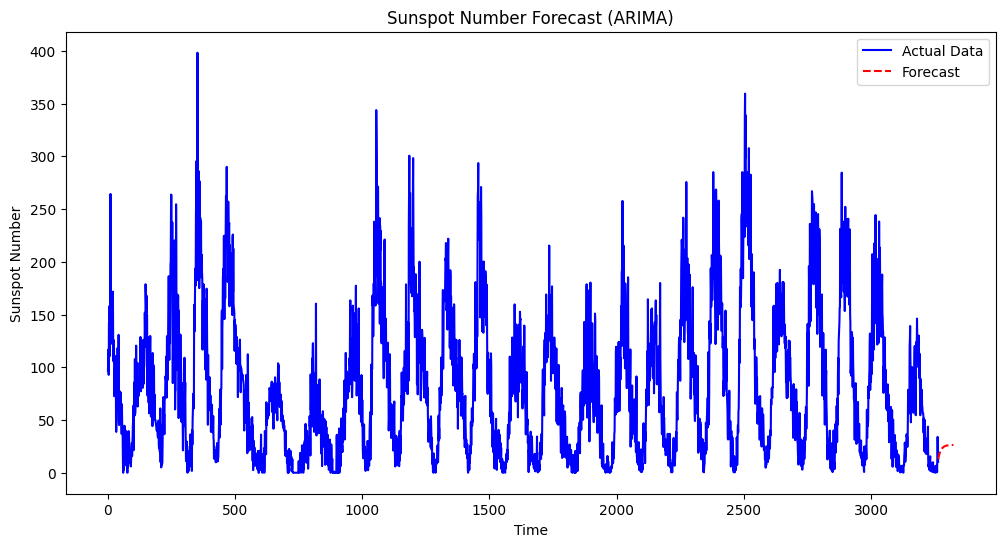

In [51]:
# Vẽ biểu đồ dữ liệu thực tế và dự báo
plt.figure(figsize=(12, 6))
plt.plot(sunspots, label='Actual Data', color='blue')
plt.plot(forecast, label='Forecast', color='red', linestyle='--')
plt.title('Sunspot Number Forecast (ARIMA)')
plt.xlabel('Time')
plt.ylabel('Sunspot Number')
plt.legend()
plt.show()

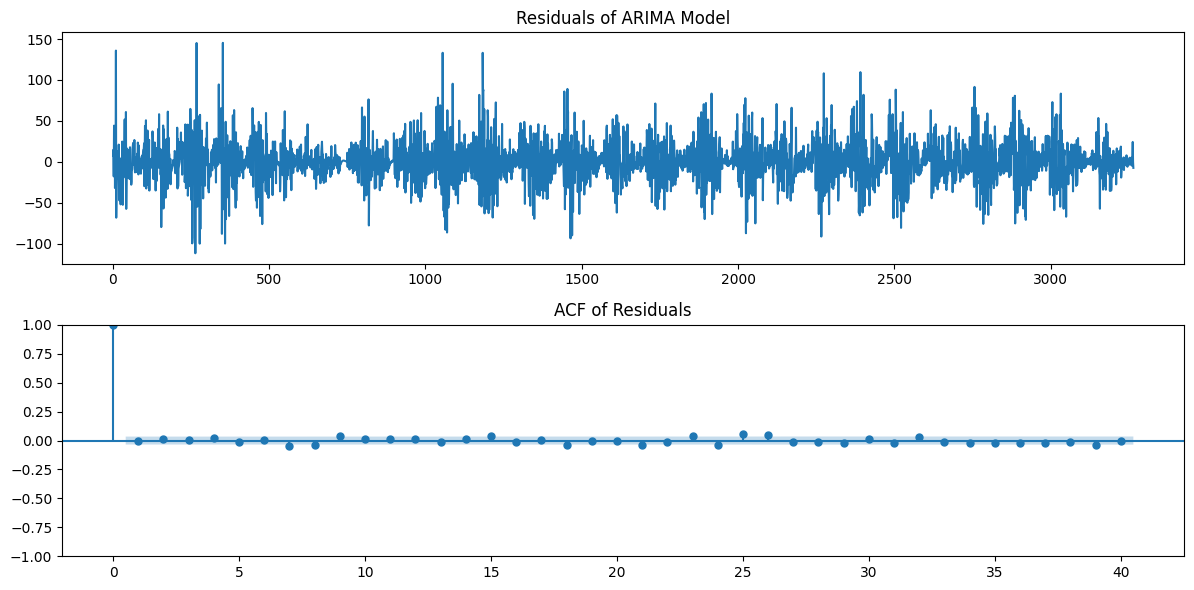


Kiểm định Ljung-Box:
      lb_stat  lb_pvalue
10  21.659746   0.016935


In [52]:
# Kiểm tra phần dư
residuals = model_fit.resid[1:]  # Bỏ giá trị đầu tiên do sai phân
plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(residuals)
plt.title('Residuals of ARIMA Model')
plt.subplot(212)
plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('ACF of Residuals')
plt.tight_layout()
plt.show()

# Kiểm định Ljung-Box để kiểm tra tự tương quan trong phần dư
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("\nKiểm định Ljung-Box:")
print(lb_test)